# 📁 Notebook 01 — Case Base
## Sistem Case-Based Reasoning (CBR) untuk Putusan Penadahan

**Tahap 1: Case Base**

Notebook ini melakukan:
1. Pembacaan seluruh PDF dari `data/raw/pdf/`
2. Ekstraksi teks menggunakan `pdfminer.six`
3. Pembersihan teks (header, footer, nomor halaman, whitespace, lowercase)
4. Penyimpanan TXT ke `data/raw/txt/`
5. Pencatatan log ke `logs/cleaning.log`
6. Pembuatan dataset awal `data/processed/cases.csv`
7. Validasi akhir


## Cell 1 — Setup & Import Library

Mengimpor semua library yang dibutuhkan dan memvalidasi ketersediaannya.

In [ ]:
# ── Library standar ────────────────────────────────────────────────────────────
import os
import re
import sys
import logging
import traceback
from pathlib import Path
from datetime import datetime

# ── Data processing ────────────────────────────────────────────────────────────
import pandas as pd

# ── PDF extraction ─────────────────────────────────────────────────────────────
from pdfminer.high_level import extract_text
from pdfminer.pdfparser import PDFSyntaxError

# ── Verifikasi versi ───────────────────────────────────────────────────────────
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")

import pdfminer
print(f"pdfminer.six: {pdfminer.__version__}")
print()
print(" Semua library berhasil diimpor.")


Python      : 3.13.0
pandas      : 2.2.3
pdfminer.six: 20260107

✅ Semua library berhasil diimpor.


## Cell 2 — Konfigurasi Path Proyek

Mendefinisikan semua path yang digunakan secara terpusat.  
Ubah `BASE_DIR` jika lokasi folder proyek berbeda.


In [11]:
# ── Konfigurasi path ───────────────────────────────────────────────────────────
# Sesuaikan BASE_DIR dengan lokasi folder proyek Anda
BASE_DIR       = Path("..").resolve()          # satu level di atas folder notebooks/

PDF_DIR        = BASE_DIR / "data" / "raw"  / "pdf"
TXT_DIR        = BASE_DIR / "data" / "raw"  / "txt"
PROCESSED_DIR  = BASE_DIR / "data" / "processed"
LOG_DIR        = BASE_DIR / "logs"

CASES_CSV      = PROCESSED_DIR / "cases.csv"
CLEANING_LOG   = LOG_DIR       / "cleaning.log"

# ── Buat direktori jika belum ada ─────────────────────────────────────────────
for d in [PDF_DIR, TXT_DIR, PROCESSED_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Tampilkan path ─────────────────────────────────────────────────────────────
print("Konfigurasi Path:")
print(f"  BASE_DIR      : {BASE_DIR}")
print(f"  PDF_DIR       : {PDF_DIR}")
print(f"  TXT_DIR       : {TXT_DIR}")
print(f"  PROCESSED_DIR : {PROCESSED_DIR}")
print(f"  LOG_DIR       : {LOG_DIR}")
print(f"  CASES_CSV     : {CASES_CSV}")
print(f"  CLEANING_LOG  : {CLEANING_LOG}")


Konfigurasi Path:
  BASE_DIR      : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN
  PDF_DIR       : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/pdf
  TXT_DIR       : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/txt
  PROCESSED_DIR : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed
  LOG_DIR       : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/logs
  CASES_CSV     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv
  CLEANING_LOG  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/logs/cleaning.log


## Cell 3 — Setup Logger

Menyiapkan logger yang menulis ke:
- `logs/cleaning.log` (file permanen)
- Console / output Jupyter (tampilan langsung)


In [3]:
def setup_logger(log_path: Path) -> logging.Logger:
    """
    Membuat logger dengan dua handler:
    - FileHandler  → menulis ke logs/cleaning.log
    - StreamHandler → menampilkan ke output Jupyter
    """
    logger = logging.getLogger("cbr_case_base")
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()           # hindari duplikasi jika cell dijalankan ulang

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Handler ke file
    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    # Handler ke console
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(formatter)
    logger.addHandler(ch)

    return logger


logger = setup_logger(CLEANING_LOG)
logger.info("=" * 70)
logger.info("CBR PENADAHAN — TAHAP 1: CASE BASE")
logger.info(f"Waktu mulai : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
logger.info(f"PDF_DIR     : {PDF_DIR}")
logger.info(f"TXT_DIR     : {TXT_DIR}")
logger.info("=" * 70)


2026-06-25 19:20:27 | INFO     | ======================================================================
2026-06-25 19:20:27 | INFO     | CBR PENADAHAN — TAHAP 1: CASE BASE
2026-06-25 19:20:27 | INFO     | Waktu mulai : 2026-06-25 19:20:27
2026-06-25 19:20:27 | INFO     | PDF_DIR     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/pdf
2026-06-25 19:20:27 | INFO     | TXT_DIR     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/txt
2026-06-25 19:20:27 | INFO     | ======================================================================


## Cell 4 — Fungsi Ekstraksi Teks dari PDF

Mengekstrak teks mentah dari satu file PDF menggunakan `pdfminer.six`.  
Menangani error tanpa menghentikan seluruh proses (try/except per file).


In [ ]:
def ekstrak_teks_pdf(pdf_path: Path) -> tuple[str, str]:
    """
    Mengekstrak teks mentah dari satu file PDF.

    Parameters
    ----------
    pdf_path : Path
        Path ke file PDF.

    Returns
    -------
    tuple[str, str]
        (teks_mentah, pesan_error)
        Jika sukses : (teks, "")
        Jika gagal  : ("", pesan_error)
    """
    try:
        raw_text = extract_text(str(pdf_path))
        if not raw_text or raw_text.strip() == "":
            return "", "Teks kosong — kemungkinan PDF hasil scan (image-only)"
        return raw_text, ""

    except PDFSyntaxError as e:
        return "", f"PDFSyntaxError: {e}"
    except FileNotFoundError:
        return "", f"File tidak ditemukan: {pdf_path}"
    except Exception as e:
        return "", f"Error tidak terduga: {type(e).__name__}: {e}"


# ── Uji cepat dengan 1 file ────────────────────────────────────────────────────
sample_pdfs = sorted(PDF_DIR.glob("*.pdf"))
if sample_pdfs:
    sample_file = sample_pdfs[0]
    raw, err = ekstrak_teks_pdf(sample_file)
    if err:
        print(f" Gagal: {err}")
    else:
        print(f" Uji ekstraksi berhasil: {sample_file.name}")
        print(f"   Panjang teks mentah : {len(raw):,} karakter")
        print(f"   Preview 200 karakter :")
        print("   " + "-" * 60)
        print("   " + raw[:200].replace("\n", " "))
else:
    print("  Tidak ada file PDF di PDF_DIR. Letakkan file PDF terlebih dahulu.")


✅ Uji ekstraksi berhasil: case_001.pdf
   Panjang teks mentah : 20,410 karakter
   Preview 200 karakter :
   ------------------------------------------------------------
   Direktori Putusan Mahkamah Agung Republik Indonesia putusan.mahkamahagung.go.id  Mahkamah Agung Republik Indonesia Mahkamah Agung Republik Indonesia Mahkamah Agung Republik Indonesia Mahkamah Agung Re


## Cell 5 — Fungsi Pembersihan Teks

Membersihkan teks mentah dari PDF putusan pengadilan:

| Langkah | Tindakan |
|---------|----------|
| 1 | Hapus baris yang mengandung pola nomor halaman (`Halaman N dari M`, `- N -`, `Page N`) |
| 2 | Hapus baris pendek berulang yang merupakan artefak header/footer (≤ 4 kata & huruf kapital semua) |
| 3 | Hapus karakter non-alfanumerik berlebih (kecuali tanda baca dasar) |
| 4 | Normalisasi whitespace (tab, spasi ganda, baris kosong berlebih) |
| 5 | Lowercase seluruh teks |
| 6 | Strip baris per baris |


In [5]:
# ── Pola regex untuk nomor halaman ────────────────────────────────────────────
POLA_HALAMAN = re.compile(
    r"""
    (                          # grup utama
        halaman\s+\d+\s+dari\s+\d+   # → "halaman 1 dari 15"
      | \bpage\s+\d+\b               # → "page 3"
      | \bhal\.?\s*\d+\b            # → "hal. 5" / "hal 5"
      | ^\s*-\s*\d+\s*-\s*$         # → "- 5 -"  (baris sendiri)
      | ^\s*\d+\s*$                   # → baris berisi angka saja
    )
    """,
    re.IGNORECASE | re.VERBOSE | re.MULTILINE
)

# ── Pola header/footer pendek all-caps (artefak layout) ───────────────────────
POLA_HEADER_CAPS = re.compile(
    r"^[A-Z\s\.\-\/]{5,60}$",       # baris 5-60 char, huruf kapital & spasi saja
    re.MULTILINE
)

# ── Karakter yang dipertahankan ────────────────────────────────────────────────
POLA_KARAKTER_BUANG = re.compile(r"[^\w\s.,;:()\-/'\'\"\n]")


def bersihkan_teks(raw_text: str) -> str:
    """
    Membersihkan teks mentah hasil ekstraksi PDF.

    Parameters
    ----------
    raw_text : str
        Teks mentah dari pdfminer.

    Returns
    -------
    str
        Teks bersih, lowercase, whitespace normal.
    """
    text = raw_text

    # 1. Hapus pola nomor halaman
    text = POLA_HALAMAN.sub(" ", text)

    # 2. Hapus baris header/footer all-caps pendek
    #    (sering muncul sebagai artefak layout putusan)
    lines = text.split("\n")
    lines_bersih = []
    for line in lines:
        stripped = line.strip()
        # Pertahankan baris kosong (dipakai sebagai pemisah paragraf)
        if stripped == "":
            lines_bersih.append("")
            continue
        # Buang baris all-caps ≤ 6 kata yang kemungkinan header/footer
        words = stripped.split()
        if (stripped.isupper() and len(words) <= 6
                and not any(kw in stripped.lower()
                            for kw in ["mengadili", "memutus", "menimbang",
                                       "putusan", "demi", "terdakwa"])):
            continue
        lines_bersih.append(line)
    text = "\n".join(lines_bersih)

    # 3. Hapus karakter tidak perlu (bukan alfanumerik & tanda baca dasar)
    text = POLA_KARAKTER_BUANG.sub(" ", text)

    # 4. Normalisasi whitespace
    #    a. Ganti tab dengan spasi
    text = text.replace("\t", " ")
    #    b. Ganti spasi ganda+ dengan satu spasi
    text = re.sub(r" {2,}", " ", text)
    #    c. Ganti 3+ baris kosong dengan 2 baris kosong
    text = re.sub(r"\n{3,}", "\n\n", text)

    # 5. Strip per baris
    text = "\n".join(line.strip() for line in text.split("\n"))

    # 6. Lowercase
    text = text.lower()

    # 7. Strip keseluruhan
    text = text.strip()

    return text


# ── Uji fungsi pembersihan ─────────────────────────────────────────────────────
if sample_pdfs:
    raw_sample, _ = ekstrak_teks_pdf(sample_pdfs[0])
    bersih_sample  = bersihkan_teks(raw_sample)
    print("Perbandingan sebelum & sesudah pembersihan:")
    print(f"  Panjang mentah  : {len(raw_sample):,} karakter")
    print(f"  Panjang bersih  : {len(bersih_sample):,} karakter")
    print(f"  Reduksi         : {len(raw_sample)-len(bersih_sample):,} karakter")
    print()
    print("── Teks bersih (200 karakter pertama) ──")
    print(bersih_sample[:200])


Perbandingan sebelum & sesudah pembersihan:
  Panjang mentah  : 20,410 karakter
  Panjang bersih  : 20,146 karakter
  Reduksi         : 264 karakter

── Teks bersih (200 karakter pertama) ──
direktori putusan mahkamah agung republik indonesia
putusan.mahkamahagung.go.id

mahkamah agung republik indonesia
mahkamah agung republik indonesia
mahkamah agung republik indonesia
mahkamah agung re


## Cell 6 — Proses Semua PDF → TXT

Membaca setiap PDF, mengekstrak, membersihkan, dan menyimpan ke `data/raw/txt/`.

Format nama output: `case_001.txt`, `case_002.txt`, dst.  
File diurutkan berdasarkan nama asli PDF agar urutan konsisten.


In [ ]:
# ── Temukan semua PDF ─────────────────────────────────────────────────────────
semua_pdf = sorted(PDF_DIR.glob("*.pdf"))
total_pdf  = len(semua_pdf)

logger.info(f"Ditemukan {total_pdf} file PDF di {PDF_DIR}")

if total_pdf == 0:
    print(f"  Tidak ada file PDF di: {PDF_DIR}")
    print("    Letakkan 50 file PDF putusan ke dalam folder tersebut, lalu jalankan ulang cell ini.")
else:
    print(f" Ditemukan {total_pdf} file PDF. Memulai proses ekstraksi...")
    print()

# ── Proses per file ───────────────────────────────────────────────────────────
records   = []    # untuk cases.csv
gagal     = []    # file yang gagal diproses
sukses    = 0

for idx, pdf_path in enumerate(semua_pdf, start=1):
    case_id  = f"case_{idx:03d}"
    txt_name = f"{case_id}.txt"
    txt_path = TXT_DIR / txt_name

    logger.info(f"[{idx:03d}/{total_pdf}] Memproses: {pdf_path.name}")

    # Ekstrak
    raw_text, err_ekstrak = ekstrak_teks_pdf(pdf_path)

    if err_ekstrak:
        logger.warning(f"  GAGAL EKSTRAK → {err_ekstrak}")
        gagal.append({"file": pdf_path.name, "alasan": err_ekstrak})
        records.append({
            "case_id"      : case_id,
            "file_name"    : pdf_path.name,
            "txt_file"     : "",
            "status"       : "GAGAL",
            "alasan_gagal" : err_ekstrak,
            "len_raw"      : 0,
            "len_clean"    : 0,
            "text_full"    : ""
        })
        continue

    # Bersihkan
    clean_text = bersihkan_teks(raw_text)

    if len(clean_text.strip()) < 50:
        alasan = "Teks bersih terlalu pendek (<50 karakter) — kemungkinan PDF corrupt atau scan"
        logger.warning(f"  DITOLAK → {alasan}")
        gagal.append({"file": pdf_path.name, "alasan": alasan})
        records.append({
            "case_id"      : case_id,
            "file_name"    : pdf_path.name,
            "txt_file"     : "",
            "status"       : "GAGAL",
            "alasan_gagal" : alasan,
            "len_raw"      : len(raw_text),
            "len_clean"    : len(clean_text),
            "text_full"    : ""
        })
        continue

    # Simpan TXT
    try:
        txt_path.write_text(clean_text, encoding="utf-8")
        logger.info(f"  OK — {txt_name} ({len(clean_text):,} char)")
        sukses += 1
        records.append({
            "case_id"      : case_id,
            "file_name"    : pdf_path.name,
            "txt_file"     : txt_name,
            "status"       : "SUKSES",
            "alasan_gagal" : "",
            "len_raw"      : len(raw_text),
            "len_clean"    : len(clean_text),
            "text_full"    : clean_text
        })
    except OSError as e:
        alasan = f"Gagal menulis TXT: {e}"
        logger.error(f"  ERROR → {alasan}")
        gagal.append({"file": pdf_path.name, "alasan": alasan})
        records.append({
            "case_id"      : case_id,
            "file_name"    : pdf_path.name,
            "txt_file"     : "",
            "status"       : "GAGAL",
            "alasan_gagal" : alasan,
            "len_raw"      : len(raw_text),
            "len_clean"    : len(clean_text),
            "text_full"    : ""
        })

print(f"\nProses selesai: {sukses}/{total_pdf} file berhasil.")
if gagal:
    print(f"  {len(gagal)} file gagal (lihat Cell 8 untuk detail).")


2026-06-25 19:21:16 | INFO     | Ditemukan 50 file PDF di /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/pdf
✅ Ditemukan 50 file PDF. Memulai proses ekstraksi...

2026-06-25 19:21:16 | INFO     | [001/50] Memproses: case_001.pdf
2026-06-25 19:21:16 | INFO     |   OK — case_001.txt (20,146 char)
2026-06-25 19:21:16 | INFO     | [002/50] Memproses: case_002.pdf
2026-06-25 19:21:16 | INFO     |   OK — case_002.txt (34,221 char)
2026-06-25 19:21:16 | INFO     | [003/50] Memproses: case_003.pdf
2026-06-25 19:21:17 | INFO     |   OK — case_003.txt (82,285 char)
2026-06-25 19:21:17 | INFO     | [004/50] Memproses: case_004.pdf
2026-06-25 19:21:17 | INFO     |   OK — case_004.txt (41,460 char)
2026-06-25 19:21:17 | INFO     | [005/50] Memproses: case_005.pdf
2026-06-25 19:21:18 | INFO     |   OK — case_005.txt (36,622 char)
2026-06-25 19:21:18 | INFO     | [006/50] Memproses: case_006.pdf
2026-06-25 19:21:21 | INFO     |   OK — case_006.txt (431,110 char)
2026-0

## Cell 7 — Simpan Dataset Awal `cases.csv`

Membuat `data/processed/cases.csv` yang berisi:

| Kolom | Keterangan |
|-------|-----------|
| `case_id` | ID unik kasus (case_001 … case_050) |
| `file_name` | Nama file PDF asli |
| `txt_file` | Nama file TXT hasil ekstraksi |
| `status` | SUKSES / GAGAL |
| `alasan_gagal` | Kosong jika sukses, berisi pesan error jika gagal |
| `len_raw` | Panjang teks mentah (karakter) |
| `len_clean` | Panjang teks bersih (karakter) |
| `text_full` | Teks bersih lengkap |


In [ ]:
if not records:
    print("  Tidak ada data yang bisa disimpan. Pastikan PDF_DIR berisi file PDF.")
else:
    df = pd.DataFrame(records, columns=[
        "case_id", "file_name", "txt_file",
        "status", "alasan_gagal",
        "len_raw", "len_clean", "text_full"
    ])

    # Simpan CSV
    df.to_csv(CASES_CSV, index=False, encoding="utf-8-sig")
    logger.info(f"Dataset disimpan: {CASES_CSV}  ({len(df)} baris)")

    # Preview tanpa kolom text_full (agar output ringkas)
    print(f" Dataset tersimpan: {CASES_CSV}")
    print(f"   Jumlah baris      : {len(df)}")
    print()
    print("Preview 5 baris pertama (tanpa kolom text_full):")
    display(df.drop(columns=["text_full"]).head())


2026-06-25 19:24:29 | INFO     | Dataset disimpan: /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv  (50 baris)
✅ Dataset tersimpan: /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv
   Jumlah baris      : 50

Preview 5 baris pertama (tanpa kolom text_full):


,case_id,file_name,txt_file,status,alasan_gagal,len_raw,len_clean
0,case_001,case_001.pdf,case_001.txt,SUKSES,,20410,20146
1,case_002,case_002.pdf,case_002.txt,SUKSES,,34412,34221
2,case_003,case_003.pdf,case_003.txt,SUKSES,,82982,82285
3,case_004,case_004.pdf,case_004.txt,SUKSES,,41874,41460
4,case_005,case_005.pdf,case_005.txt,SUKSES,,37204,36622


## Cell 8 — Validasi Akhir

Mencetak ringkasan hasil proses Case Base:
- Jumlah PDF ditemukan vs berhasil diproses
- Statistik panjang teks
- Daftar file gagal (jika ada)
- Konfirmasi path output


In [ ]:
# ── Hitung statistik dari df ──────────────────────────────────────────────────
df_sukses = df[df["status"] == "SUKSES"]
df_gagal  = df[df["status"] == "GAGAL"]

rata_raw   = df_sukses["len_raw"].mean()   if len(df_sukses) > 0 else 0
rata_clean = df_sukses["len_clean"].mean() if len(df_sukses) > 0 else 0
min_clean  = df_sukses["len_clean"].min()  if len(df_sukses) > 0 else 0
max_clean  = df_sukses["len_clean"].max()  if len(df_sukses) > 0 else 0

# ── Cetak ringkasan ───────────────────────────────────────────────────────────
sep = "=" * 60
print(sep)
print("  VALIDASI AKHIR — TAHAP 1: CASE BASE")
print(sep)
print(f"  PDF ditemukan          : {total_pdf:>6}")
print(f"  TXT berhasil dibuat    : {len(df_sukses):>6}")
print(f"  File gagal             : {len(df_gagal):>6}")
print()
print(f"  Rata-rata len_raw      : {rata_raw:>10,.0f} karakter")
print(f"  Rata-rata len_clean    : {rata_clean:>10,.0f} karakter")
print(f"  Panjang teks minimum   : {min_clean:>10,.0f} karakter")
print(f"  Panjang teks maksimum  : {max_clean:>10,.0f} karakter")
print()

# ── File TXT yang ada ─────────────────────────────────────────────────────────
txt_files = sorted(TXT_DIR.glob("*.txt"))
print(f"  File TXT di TXT_DIR    : {len(txt_files):>6}")
print()

# ── Daftar file gagal ─────────────────────────────────────────────────────────
if len(df_gagal) > 0:
    print("  ⚠️  DAFTAR FILE GAGAL:")
    for _, row in df_gagal.iterrows():
        print(f"     • {row['file_name']:40s} → {row['alasan_gagal']}")
else:
    print("   Tidak ada file yang gagal.")

print()
print("  OUTPUT FILES:")
print(f"     TXT  : {TXT_DIR}")
print(f"     CSV  : {CASES_CSV}")
print(f"     LOG  : {CLEANING_LOG}")
print(sep)

# ── Log penutup ───────────────────────────────────────────────────────────────
logger.info("=" * 70)
logger.info("RINGKASAN AKHIR")
logger.info(f"  PDF ditemukan        : {total_pdf}")
logger.info(f"  TXT berhasil dibuat  : {len(df_sukses)}")
logger.info(f"  File gagal           : {len(df_gagal)}")
logger.info(f"  Rata-rata len_clean  : {rata_clean:.0f} char")
logger.info("=" * 70)
logger.info("Tahap 1 selesai.")


  VALIDASI AKHIR — TAHAP 1: CASE BASE
  PDF ditemukan          :     50
  TXT berhasil dibuat    :     50
  File gagal             :      0

  Rata-rata len_raw      :     79,171 karakter
  Rata-rata len_clean    :     78,430 karakter
  Panjang teks minimum   :     12,651 karakter
  Panjang teks maksimum  :    656,132 karakter

  File TXT di TXT_DIR    :     50

  ✅ Tidak ada file yang gagal.

  OUTPUT FILES:
     TXT  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/txt
     CSV  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv
     LOG  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/logs/cleaning.log
2026-06-25 19:24:40 | INFO     | ======================================================================
2026-06-25 19:24:40 | INFO     | RINGKASAN AKHIR
2026-06-25 19:24:40 | INFO     |   PDF ditemukan        : 50
2026-06-25 19:24:40 | INFO     |   TXT berhasil dibuat  : 50
2026-06-25

## Cell 9 — Preview `cleaning.log`

Menampilkan 40 baris pertama dari log file untuk konfirmasi.


In [ ]:
# ── Tampilkan isi log ─────────────────────────────────────────────────────────
if CLEANING_LOG.exists():
    lines_log = CLEANING_LOG.read_text(encoding="utf-8").splitlines()
    print(f"Total baris log: {len(lines_log)}")
    print("─" * 70)
    # Tampilkan 40 baris pertama
    for baris in lines_log[:40]:
        print(baris)
    if len(lines_log) > 40:
        print(f"  ... (dan {len(lines_log)-40} baris lagi — buka file log untuk detail lengkap)")
else:
    print(f"  Log belum ada: {CLEANING_LOG}")


Total baris log: 116
──────────────────────────────────────────────────────────────────────
2026-06-25 19:20:27 | INFO     | ======================================================================
2026-06-25 19:20:27 | INFO     | CBR PENADAHAN — TAHAP 1: CASE BASE
2026-06-25 19:20:27 | INFO     | Waktu mulai : 2026-06-25 19:20:27
2026-06-25 19:20:27 | INFO     | PDF_DIR     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/pdf
2026-06-25 19:20:27 | INFO     | TXT_DIR     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/txt
2026-06-25 19:20:27 | INFO     | ======================================================================
2026-06-25 19:21:16 | INFO     | Ditemukan 50 file PDF di /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/raw/pdf
2026-06-25 19:21:16 | INFO     | [001/50] Memproses: case_001.pdf
2026-06-25 19:21:16 | INFO     |   OK — case_001.txt (20,146 char)
2026-06-25 19:21:16 | INFO     

## Cell 10 — Ringkasan & Langkah Selanjutnya

### ✅ Tahap 1 — Case Base Selesai

**Output yang dihasilkan:**

| Output | Lokasi |
|--------|--------|
| File TXT per kasus | `data/raw/txt/case_001.txt` … `case_N.txt` |
| Dataset CSV | `data/processed/cases.csv` |
| Log pembersihan | `logs/cleaning.log` |

**Kolom utama di `cases.csv`:**

| Kolom | Keterangan |
|-------|-----------|
| `case_id` | Identitas unik kasus |
| `file_name` | Nama PDF asli |
| `txt_file` | Nama TXT hasil ekstraksi |
| `status` | SUKSES / GAGAL |
| `len_clean` | Panjang teks bersih |
| `text_full` | Teks bersih lengkap (digunakan tahap berikutnya) |

---





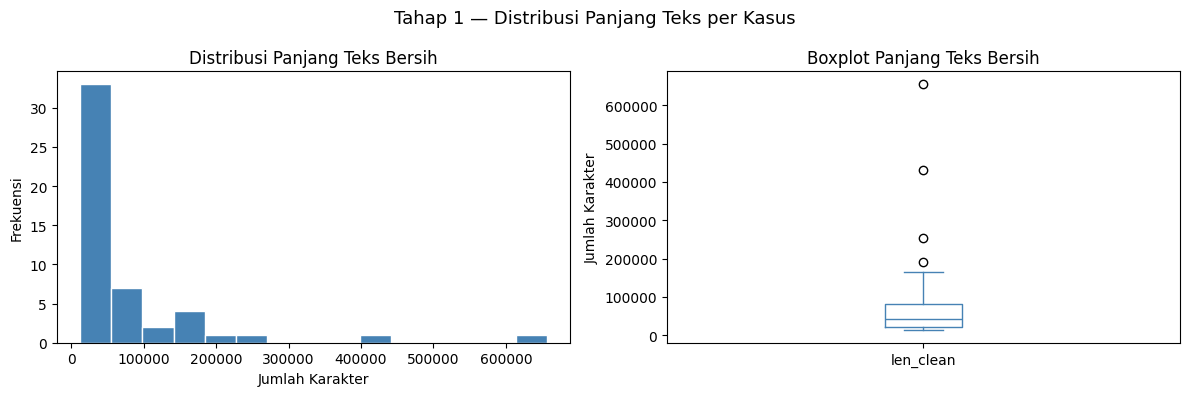

✅ Grafik disimpan ke data/results/distribusi_panjang_teks.png


In [10]:
# ── Tampilkan distribusi panjang teks (opsional, jika matplotlib tersedia) ────
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df_sukses["len_clean"].plot(
        kind="hist", bins=15, ax=axes[0],
        color="steelblue", edgecolor="white"
    )
    axes[0].set_title("Distribusi Panjang Teks Bersih")
    axes[0].set_xlabel("Jumlah Karakter")
    axes[0].set_ylabel("Frekuensi")

    df_sukses["len_clean"].plot(
        kind="box", ax=axes[1],
        color="steelblue"
    )
    axes[1].set_title("Boxplot Panjang Teks Bersih")
    axes[1].set_ylabel("Jumlah Karakter")

    plt.suptitle("Tahap 1 — Distribusi Panjang Teks per Kasus", fontsize=13)
    plt.tight_layout()
    plt.savefig(BASE_DIR / "data" / "results" / "distribusi_panjang_teks.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Grafik disimpan ke data/results/distribusi_panjang_teks.png")

except ImportError:
    print("ℹ️  matplotlib tidak tersedia — lewati visualisasi.")
except Exception as e:
    print(f"ℹ️  Grafik tidak bisa dibuat: {e}")
